In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense , LSTM

In [32]:
df = pd.read_csv("BTC-USD.csv")

In [33]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [34]:
df.shape

(2713, 7)

In [35]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [36]:
closed = df[['Date' , 'Close' ]]

In [37]:
closed.head()

,Date,Close
0,2014-09-17,457.334015
1,2014-09-18,424.440002
2,2014-09-19,394.795990
3,2014-09-20,408.903992
4,2014-09-21,398.821014


In [38]:
#plt.close()

#plt.figure(1,figsize=(12,6))

#plt.plot(closed['Date'] , closed['Close'])

#plt.show()

In [39]:
price = closed[closed['Date'] >= '2021-01-01']

In [40]:
price

,Date,Close
2298,2021-01-01,29374.152344
2299,2021-01-02,32127.267578
2300,2021-01-03,32782.023438
2301,2021-01-04,31971.914063
2302,2021-01-05,33992.429688
...,...,...
2708,2022-02-15,44575.203125
2709,2022-02-16,43961.859375
2710,2022-02-17,40538.011719
2711,2022-02-18,40030.976563


In [41]:

#plt.close()

#plt.figure(1,figsize=(12,6))

#plt.plot(price['Date'] , price['Close'])

#plt.show()

In [42]:
x = price['Close']



In [43]:
scaler = MinMaxScaler(feature_range=(0,1))
x = scaler.fit_transform(np.array(x).reshape(-1,1))

In [44]:
X_train = x[0:332]
X_test = x[332:]

In [45]:
x1=[]
y1=[]
a=[]
b=0

for i in range(len(X_train)-15-1):
    a = X_train[i:i+15,0]
    b = X_train[i+15]
    x1.append(a)
    y1.append(b)

X_train1=np.array(x1)
y_train1=np.array(y1)

print(X_train1.shape)

x1=[]
y1=[]
a=[]
b=0

for i in range(len(X_test)-15-1):
    a = X_test[i:i+15,0]
    b = X_test[i+15]
    x1.append(a)
    y1.append(b)

X_test1=np.array(x1)
y_test1=np.array(y1)

print(X_test1.shape)

(316, 15)
(67, 15)


In [46]:
X_train1=X_train1.reshape(316 , 15 , 1)
X_test1=X_test1.reshape(67 , 15 , 1)

print(X_train1.shape)
print(X_test1.shape)

(316, 15, 1)
(67, 15, 1)


In [47]:
model = Sequential()

model.add(LSTM(10 , activation='relu' , input_shape=(None , 1)))
model.add(Dense(1))

model.compile(loss="mean_squared_error" , optimizer='adam')

c:\Users\alireza\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
h = model.fit(X_train1 , y_train1 , validation_data=(X_test1 , y_test1 ), epochs=500)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3372 - val_loss: 0.1310
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2641 - val_loss: 0.0900
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1970 - val_loss: 0.0578
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1411 - val_loss: 0.0351
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0966 - val_loss: 0.0186
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0595 - val_loss: 0.0086
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0328 - val_loss: 0.0049
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0184 - val_loss: 0.0078
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0148 - val_loss: 0.0114
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0149 - val_loss: 0.0096
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - val_loss: 0.0065
Epoch 12/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

In [49]:
train_predict = model.predict(X_train1)
test_predict = model.predict(X_test1)
train_predict.shape , test_predict.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


((316, 1), (67, 1))

In [50]:
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train1.reshape(-1 , 1))
original_ytest = scaler.inverse_transform(y_test1.reshape(-1 , 1))

In [51]:
print("real: " , original_ytest[23])
print("ai: " , test_predict[23])

real:  [43160.929688]
ai:  [43842.848]


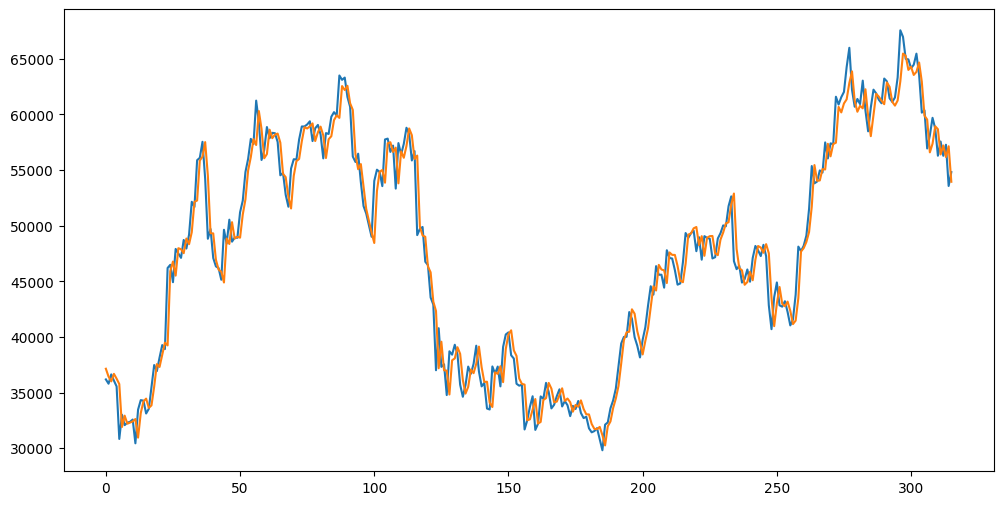

In [52]:
plt.close()

plt.figure(1 , (12,6))

plt.plot(original_ytrain)

plt.plot(train_predict)

plt.show()

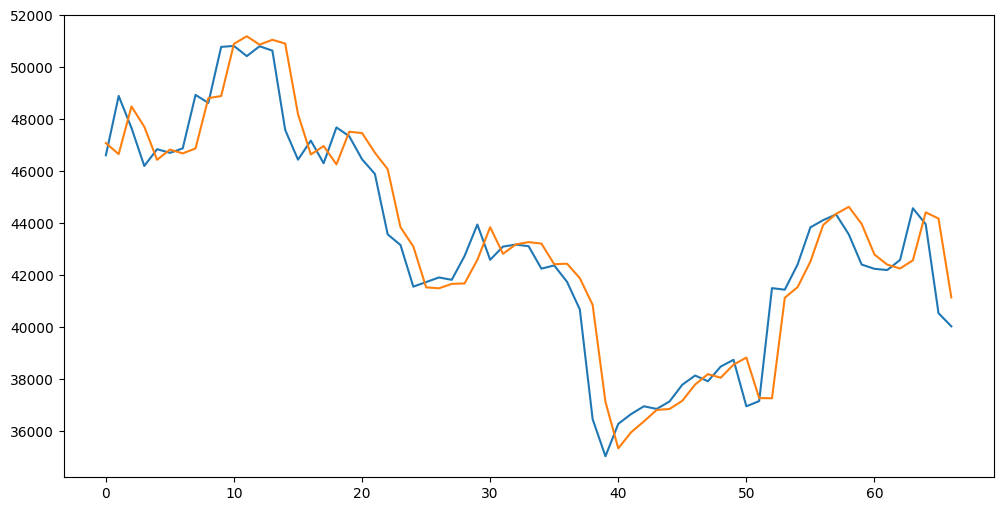

In [53]:
plt.close()

plt.figure(1 , (12,6))

plt.plot(original_ytest)

plt.plot(test_predict)

plt.show()

In [54]:
from keras_visualizer import visualizer
visualizer(model,file_name='bitcoin',file_format='png')

model.save('bitcoin.keras')